In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(r"/content/churn_dataset.csv")

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.shape

(7043, 21)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"] , errors = 'coerce')

In [9]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
data = data.dropna()

In [11]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Target Variable Distribution

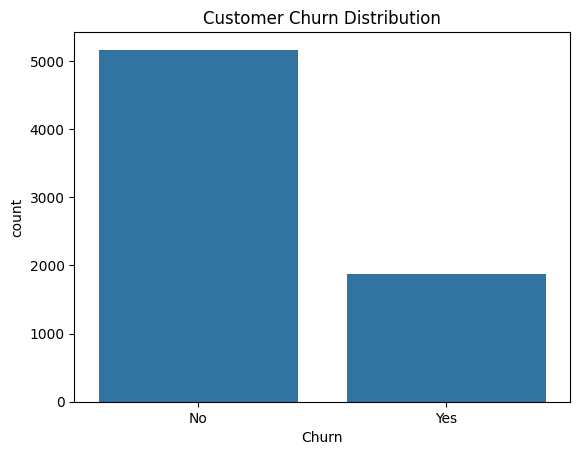

In [12]:
sns.countplot(x='Churn', data=data)
plt.title("Customer Churn Distribution")
plt.show()

***Insight***:

- Majority customers did not churn

- Around 25–30% customers left the company

***Business Meaning:***
- Telecom companies must focus on retaining customers to reduce churn rate.

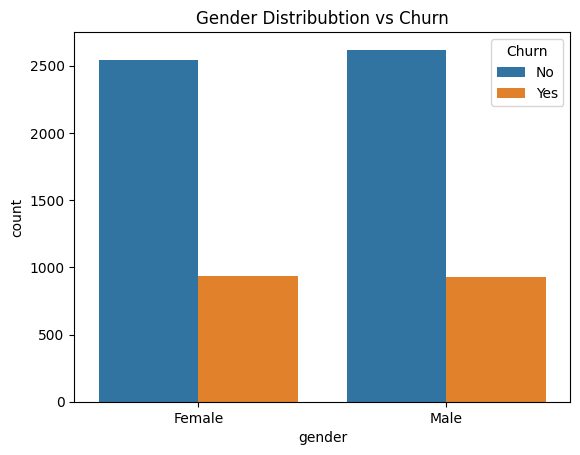

In [13]:
sns.countplot(x = 'gender' , hue = 'Churn' , data=data)
plt.title('Gender Distribubtion vs Churn')
plt.show()

- Churn rate is almost similar for male and female customers.

- Gender does not strongly influence churn.

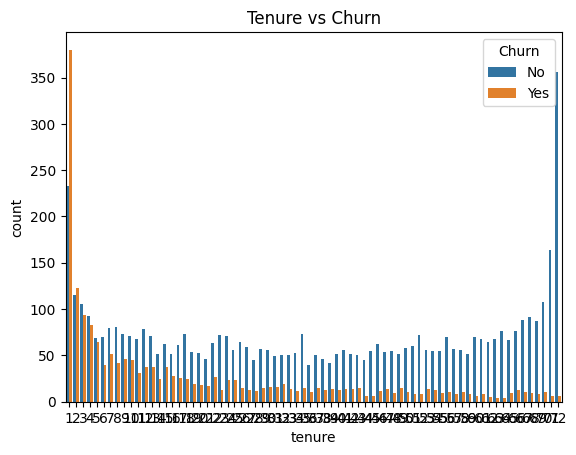

In [14]:
sns.countplot(x = 'tenure' , hue = 'Churn' , data = data)
plt.title('Tenure vs Churn')
plt.show()

***Insight :***
- Customers with low tenure churn more

- Long-term customers are more loyal

***Recommendation :***
- Focus on customer engagement during early months.

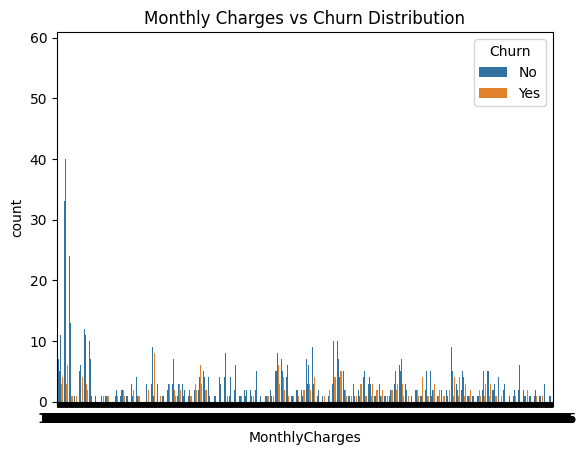

In [15]:
sns.countplot(x = 'MonthlyCharges' , hue = 'Churn' , data = data)
plt.title('Monthly Charges vs Churn Distribution')
plt.show()

***Insight***:

- Customers with higher monthly charges churn more frequently

***Recommendation :***
- Offer better pricing plans or loyalty discounts.

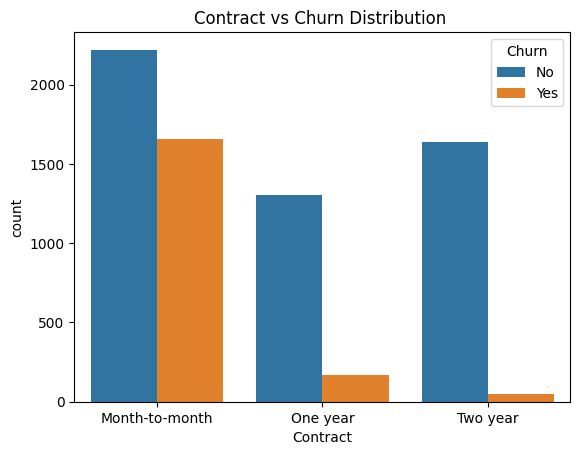

In [16]:
sns.countplot(x = 'Contract' , hue = 'Churn'  , data = data)
plt.title('Contract vs Churn Distribution ')
plt.show()

***Insight***:

- Month-to-month contract customers churn the most

- Customers with 1-year or 2-year contracts churn less

***Business Recommendation :***
- Encourage customers to take long-term contracts with discounts.

**Business Insights:**

1️⃣ Month-to-month contract customers are more likely to churn.

2️⃣ Customers with higher monthly charges tend to leave the service.

3️⃣ Customers with shorter tenure are more likely to churn.

# --- MODEL TRAINING ---

In [17]:
#Defining input and target variables
# X: input variables : Features used to make predictions : customerID
# y : Target Variable : Variable we want to predict : Churn

X = data.drop(['customerID' , 'Churn'], axis =1)
y = data['Churn']

In [18]:
#Conversion Categorical data into numerical
X = pd.get_dummies(X , drop_first=True)

In [19]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [20]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 42)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train =scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
#import evaluation matrix
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [23]:
#Model1 : KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train , y_train )
pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test , pred_knn)
print(f' KNN Accuracy Score : {acc_knn}')



 KNN Accuracy Score : 0.7536973833902162


In [24]:
#Model 2 : Logistic Regression
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train , y_train)
pred_log_reg = log_reg.predict(X_test)
acc_log_reg = accuracy_score(y_test , pred_knn)
print(f' Logistic Regression Accuracy Score : {acc_log_reg}')

 Logistic Regression Accuracy Score : 0.7536973833902162


In [25]:
#Model3 : SVM
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train , y_train)
pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test , pred_svm)
print(f' SVM Accuracy Score : {acc_svm}')

 SVM Accuracy Score : 0.7929465301478953


In [26]:
#Model4 : Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train , y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test ,pred_dt)
print(f' Decision Tree Accuracy Score : {acc_dt}')

 Decision Tree Accuracy Score : 0.7138794084186576


In [27]:
#Model5 : Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train , y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test , pred_rf)
print(f' Random Forest Accuracy Score : {acc_dt}')

 Random Forest Accuracy Score : 0.7138794084186576


/tmp/ipykernel_902/759494962.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


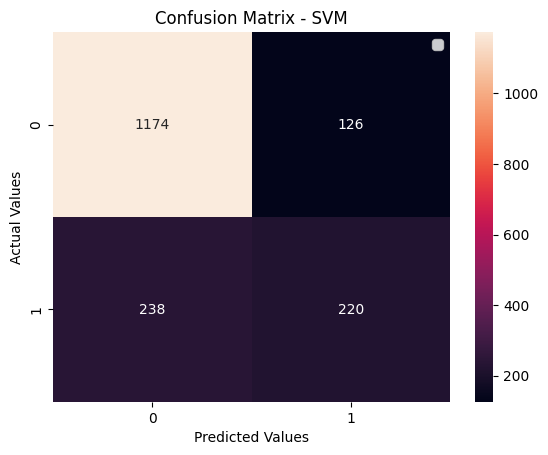

In [28]:
#Confusion matrix for SVM
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix( y_test, pred_svm)
sns.heatmap(cm , annot=True , fmt = 'd')
plt.title("Confusion Matrix - SVM")
plt.xlabel ("Predicted Values")
plt.ylabel ("Actual Values")
plt.legend()
plt.show()

**Final Business Recommendation:
Based on analysis:**

1️⃣ Customers with month-to-month contracts churn more

2️⃣ Customers with higher monthly charges are more likely to leave

3️⃣ Customers with low tenure churn more frequently

**Recommendations:**
- Offer discounts for long-term contracts
- Provide loyalty benefits
- Improve customer support services
- Identify high-risk churn customers early

In [29]:
import pickle

pickle.dump(svm, open("churn_model.pkl", "wb"))

In [30]:
import pandas as pd
from sklearn.svm import SVC
import pickle

# load dataset
df = pd.read_csv("churn_dataset.csv")

# use only the same inputs as Streamlit
X = df[["tenure", "MonthlyCharges"]]
y = df["Churn"]

# train model
model = SVC()
model.fit(X, y)

# save model
pickle.dump(model, open("churn_model.pkl", "wb"))

print("New model saved successfully")

New model saved successfully
